# **Análisis de Datos Experimentales: Interpolación y Regresión Numérica.**
En este notebook se presentan diferentes métodos numéricos para el análisis de datos experimentales, abordando técnicas de **interpolación** y **regresión**. Se aplicarán estos métodos a un conjunto de datos proporcionados, con el objetivo de encontrar modelos matemáticos que describan su comportamiento. Las técnicas utilizadas incluyen:

- **Interpolación de Lagrange**: Construcción de polinomios que pasan exactamente por los puntos dados.  
- **Interpolación mediante Splines Cúbicos**: Aproximación de los datos mediante funciones polinómicas por tramos.
- **Ajuste por Regresión Lineal**: Modelado de los datos con polinomios de grado 1, 2, 3 y 4, junto con una transformación logarítmica.
- **Ajuste por Regresión No Lineal**: Estimación de parámetros en modelos de la forma $f(x) = a_0 - a_1 e^{-a_2 x}$, entre otros.

Cada método será implementado en **Python**, utilizando diferentes bibliotecas, y los resultados serán visualizados mediante gráficos comparativos.


## **Introducción.**
El informe consistirá en hacer un análisis de un conjunto de datos experimentales. Cada grupo tendrá que elegir uno de los 6 archivos que se encuentran en la plataforma, denominados `Datos_GrupoN.txt`, donde $N$ representa el número del grupo. Con los datos dados en el archivo, los integrantes tendrán que realizar los siguientes ajustes:

- **[Ejercicio 1:](#ejercicio-1-interpolación-de-lagrange)** Desarrollar una función en Python que determine el polinomio de interpolación de Lagrange que se ajuste a los datos entregados.
- **[Ejercicio 2:](#ejercicio-2-interpolación-mediante-splines-cúbicos)** Desarrollar una función en Python que determine los polinomios de interpolación mediante splines cúbicos.
- **[Ejercicio 3:](#ejercicio-3-ajuste-por-regresión-lineal)** Ajustar los datos entregados mediante regresión lineal a polinomios de grado 1, 2, 3 y 4, y a la función: $y = a_0 x^{a_1}$ haciendo una transformación de los datos.
- **[Ejercicio 4:](#ejercicio-4-ajuste-por-regresión-no-lineal)** Ajustar los datos entregados mediante regresión no lineal a las siguientes funciones:
    1. $f(x) = a_0 - a_1 e^{-a_2 x}$
    2. $f(x) = a_0 x - a_1 e^{-a_2 x}$
    3. $f(x) = a_0 x^2 - a_1 e^{-a_2 x}$

## **Importaciones de librerias y datos.**
En este apartado se procederá a la importación de las librerías necesarias para la ejecución del taller, las cuales han sido previamente definidas en el archivo **`requirements.txt`**. Esto garantiza la compatibilidad del entorno de trabajo y permite realizar de manera eficiente el procesamiento de datos, el cálculo de métricas estadísticas y la visualización de resultados, asegurando así una correcta ejecución de los ejercicios posteriores.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

pd.set_option('display.max_colwidth', None)
colores = ["#2E8B57", "#FF5733"]

In [7]:
# Función para leer los datos desde un archivo txt.
def leer_datos(archivo):
    datos = np.loadtxt(archivo)
    x = datos[:, 0]
    y = datos[:, 1]
    return x, y

In [8]:
path = "../data"
x_data, y_data = leer_datos(f"{path}/Datos_Grupo_2.txt")

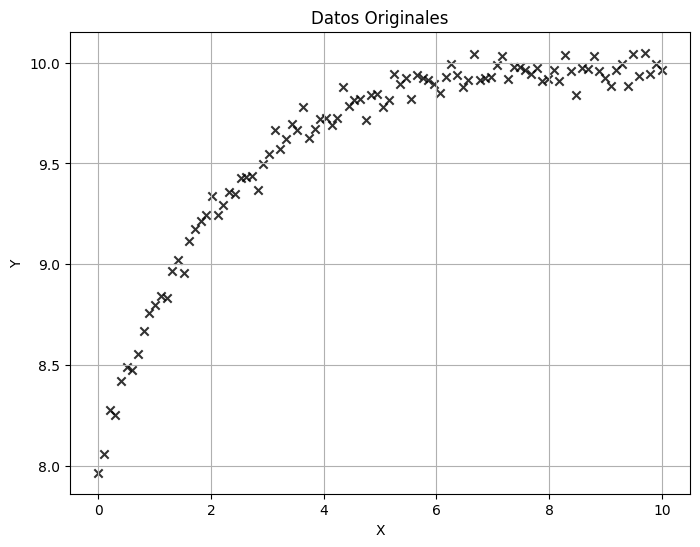

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_data, color='black', marker='x', alpha=0.8)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos Originales")
plt.grid(True)
plt.savefig("../figures/informe-01/datos.png")
plt.show()

## **Ejercicio 1: Interpolación de Lagrange.**
En este ejercicio, se implementa el **polinomio de interpolación de Lagrange**, un método utilizado para encontrar un polinomio que pase exactamente por un conjunto de puntos dados. La **interpolación de Lagrange** evita el cálculo de diferencias divididas y se basa en la construcción de funciones base $L_i(x)$, las cuales se combinan para formar el polinomio interpolador:

$$
f_n(x) = \sum_{i=0}^{n} L_i(x) f(x_i)
$$

dónde cada función base $L_i(x)$ se define como:

$$
L_i(x) = \prod_{\substack{j=0 \\ j\neq i}}^{n} \frac{x - x_j}{x_i - x_j}
$$

### Definición de funciones para Interpolación de Lagrange.

In [10]:
# Función para calcular los coeficientes de Lagrange L_i(x)
def lagrange_basis(x, x_data, i):
    n = len(x_data)
    L_i = 1
    for j in range(n):
        if j != i:
            L_i *= (x - x_data[j]) / (x_data[i] - x_data[j])
    return L_i

In [11]:
# Función para calcular el polinomio de interpolación de Lagrange
def polinomio_lagrange(x, x_data, y_data):
    n = len(x_data)
    resultado = 0
    for i in range(n):
        resultado += y_data[i] * lagrange_basis(x, x_data, i)
    return resultado

### Implementación de la interpolación de Lagrange con los datos.

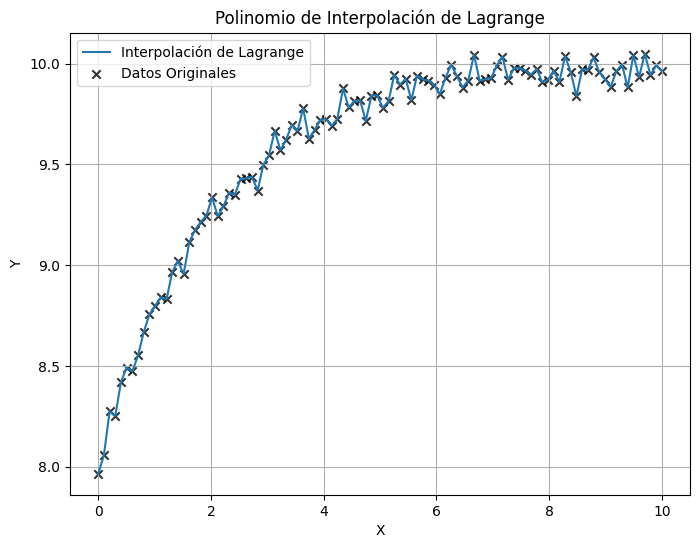

In [12]:
x_vals = np.linspace(0, 10, 100)
y_vals = np.array([polinomio_lagrange(x, x_data, y_data) for x in x_vals])

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="Interpolación de Lagrange")
plt.scatter(x_data, y_data, color='black', label="Datos Originales", marker='x', alpha=0.8)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polinomio de Interpolación de Lagrange")
plt.legend()
plt.grid(True)
plt.savefig("../figures/informe-01/lagrange.png")
plt.show()

## **Ejercicio 2: Interpolación mediante Splines Cúbicos.**
En este ejercicio se aplica la interpolación con Splines Cúbicos para modelar un conjunto de datos, proporcionando una aproximación suave y precisa. A diferencia de otros métodos de interpolación polinómica, los Splines Cúbicos dividen el dominio en múltiples subintervalos y ajustan polinomios de tercer grado en cada uno, garantizando continuidad en la función y sus derivadas.

### Definición de funciones para Splines Cúbicos.

In [13]:
# Construcción del spline cúbico natural. Devuelve los coeficientes de los polinomios por tramos.
def spline_cubico(x_data, y_data):
    n = len(x_data) - 1  # Número de intervalos.
    h = np.diff(x_data)  # Tamaño de cada subintervalo.
    b = np.diff(y_data) / h  # Diferencias divididas.

    # Matriz tridiagonal y vector de términos independientes.
    A = np.zeros((n + 1, n + 1))
    b_vec = np.zeros(n + 1)

    # Condiciones de frontera naturales.
    A[0, 0] = 1
    A[n, n] = 1

    for i in range(1, n):
        A[i, i - 1] = h[i - 1]
        A[i, i] = 2 * (h[i - 1] + h[i])
        A[i, i + 1] = h[i]
        b_vec[i] = 3 * (b[i] - b[i - 1])

    # Resolución del sistema tridiagonal para obtener segunda derivada (c coeficientes)
    c = np.linalg.solve(A, b_vec)

    # Calcular coeficientes a, b, c, d para cada subintervalo
    a = y_data[:-1]
    d = np.diff(c) / (3 * h)
    b = b - h * (2 * c[:-1] + c[1:]) / 3

    return a, b, c[:-1], d, x_data

In [14]:
# Evaluación del spline cúbico en un conjunto de puntos x.
def evaluar_spline(x, x_data, a, b, c, d):
    n = len(x_data) - 1
    y_vals = np.zeros_like(x)
    
    for i in range(n):
        indices = (x >= x_data[i]) & (x <= x_data[i + 1])
        dx = x[indices] - x_data[i]
        y_vals[indices] = a[i] + b[i] * dx + c[i] * dx**2 + d[i] * dx**3

    return y_vals

### Implementación de la interpolación de Splines Cúbicos con los datos.

In [15]:
# Construcción del spline cúbico.
a, b, c, d, x_knots = spline_cubico(x_data, y_data)

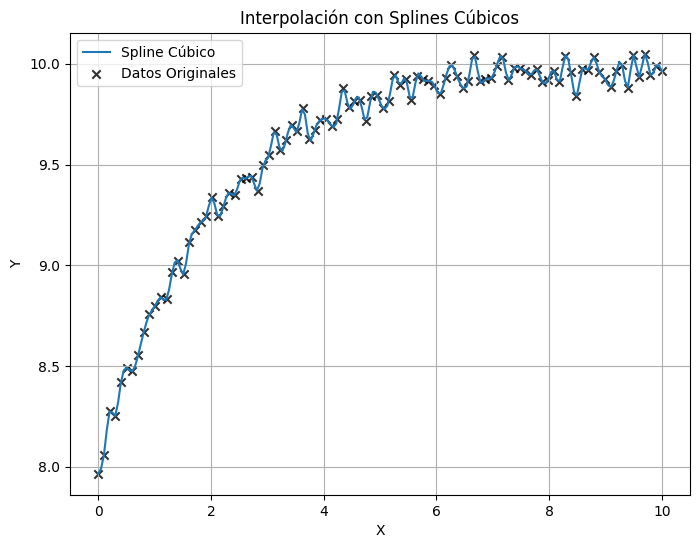

In [16]:
x_vals = np.linspace(np.min(x_data), np.max(x_data), 200)
y_vals = evaluar_spline(x_vals, x_knots, a, b, c, d)

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="Spline Cúbico")
plt.scatter(x_data, y_data, color='black', label="Datos Originales", marker='x', alpha=0.8)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Interpolación con Splines Cúbicos")
plt.legend()
plt.grid(True)
plt.savefig("../figures/informe-01/spline_cubico.png")
plt.show()

## **Ejercicio 3: Ajuste por Regresión Lineal.**
En este ejercicio, se implementa el **ajuste por regresión lineal**, un método estadístico utilizado para encontrar la relación entre una variable dependiente y una o más variables independientes. A diferencia de la interpolación, donde el polinomio pasa exactamente por los puntos dados, la **regresión lineal** busca minimizar el error entre los valores observados y los valores predichos por el modelo.

El modelo de **regresión lineal simple** se expresa como:

$$
y = a_0 + a_1 x
$$

donde $a_0$ es la ordenada en el origen y $a_1$ es la pendiente de la recta de mejor ajuste. Para ajustar un conjunto de datos a un **polinomio de grado $n$**, el modelo se generaliza como:

$$
y = a_0 + a_1 x + a_2 x^2 + \dots + a_n x^n
$$

Los coeficientes $a_i$ se determinan utilizando el **método de mínimos cuadrados**, que minimiza la suma de los errores cuadráticos:

$$
S = \sum_{i=1}^{m} (y_i - \hat{y}_i)^2
$$

### **Ajuste con Polinomios.**
En este primer apartado, se ajustarán los datos mediante regresión polinómica de grados 1, 2, 3 y 4. Se evaluará la calidad del ajuste mediante métricas como el coeficiente de determinación $R^2$.

#### Definición de funciones.
Se definirán funciones para ajustar polinomios de distintos grados y calcular métricas de calidad del ajuste.

In [17]:
# Función para ajustar un polinomio de mediante mínimos cuadrados.
def polynomial_regression(x, y, degree):
    X = np.vander(x, degree + 1, increasing=True)  # Matriz de Vandermonde.
    coeffs = np.linalg.inv(X.T @ X) @ X.T @ y  # Resolver ecuación normal.
    return coeffs

In [18]:
# Función para evaluar un polinomio en los puntos dado un conjunto de coeficientes.
def evaluate_polynomial(coeffs, x_vals):
    y_vals = np.zeros_like(x_vals)
    for i, coef in enumerate(coeffs):
        y_vals += coef * (x_vals ** i)  # Evaluación manual del polinomio.
    return y_vals

#### Implementación de las funciones.
Se aplicarán las funciones definidas a los datos proporcionados y se visualizarán los resultados.

In [19]:
degrees = [1, 2, 3, 4]
fits_manual = {}

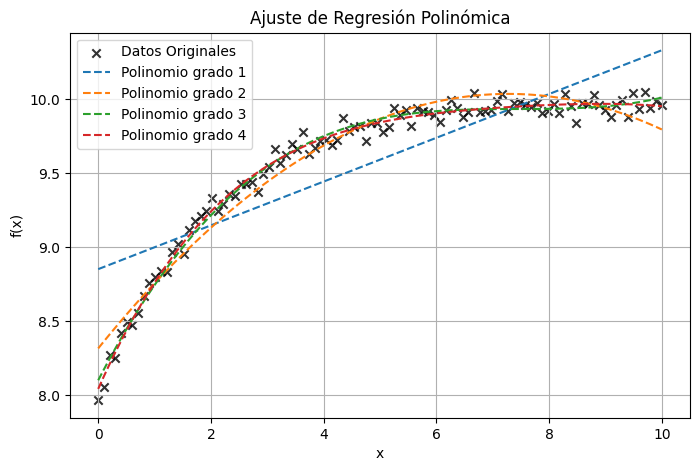

In [20]:
for d in degrees:
    coeffs = polynomial_regression(x_data, y_data, d)
    fits_manual[d] = (coeffs, evaluate_polynomial(coeffs, x_data))

# Graficar los resultados.
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, color='black', label='Datos Originales', marker='x', alpha=0.8)

# Dibujar las regresiones polinómicas.
for d, (coeffs, y_fit) in fits_manual.items():
    plt.plot(x_data, y_fit, linestyle="--", label=f'Polinomio grado {d}')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Ajuste de Regresión Polinómica")
plt.grid(True)
plt.savefig("../figures/informe-01/polinomios_manual.png")
plt.show()

In [21]:
# Calcular coeficientes y métricas de R^2.
results = []

for d, (coeffs, y_fit) in fits_manual.items():
    r2 = r2_score(y_data, y_fit)
    results.append([d, list(coeffs), r2])

df_results = pd.DataFrame(results, columns=["Grado", "Coeficientes", "R^2"])
df_results

,Grado,Coeficientes,R^2
0,1,"[8.852143257117095, 0.14804885558451897]",0.722340
1,2,"[8.316106293859868, 0.47295289249766204, -0.03249040369131639]",0.958882
2,3,"[8.100514710837464, 0.7383532525648306, -0.09917501673019331, 0.004445640869255911]",0.987903
3,4,"[8.042234870892965, 0.860439508624424, -0.1547599850066327, 0.01312090940334759, -0.0004337634267028551]",0.989690


**Código con funciones predefinidas.** Se emplearán herramientas predefinidas para verificar la validez de los resultados obtenidos manualmente: `polyfit`.

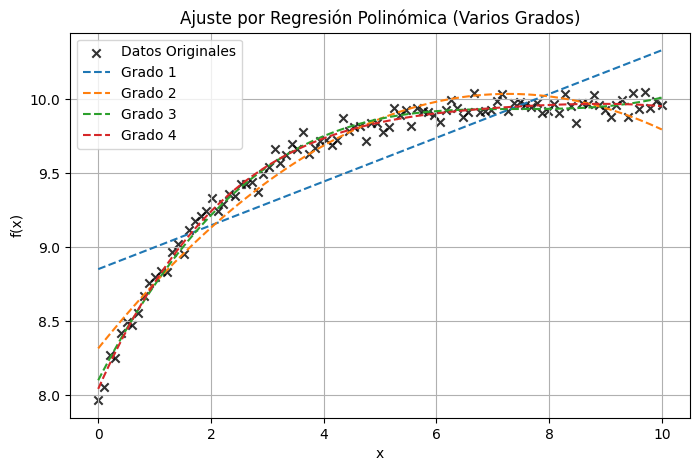

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, color='black', label='Datos Originales', marker='x', alpha=0.8)

# Iterar sobre los grados de polinomios y graficar todos en el mismo gráfico.
for grado in degrees:
    coeficientes = np.polyfit(x_data, y_data, grado)  # Ajuste polinómico.
    y_pred = np.polyval(coeficientes, x_data)  # Evaluar el polinomio ajustado.
    plt.plot(x_data, y_pred, linestyle='--', label=f'Grado {grado}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title('Ajuste por Regresión Polinómica (Varios Grados)')
plt.grid(True)
plt.show()

In [23]:
results = []

# Calcular coeficientes y métricas de R^2.
for grado in degrees:
    coeficientes = np.polyfit(x_data, y_data, grado)
    y_pred = np.polyval(coeficientes, x_data)
    r2 = r2_score(y_data, y_pred)
    results.append([grado, list(coeficientes), r2])

df_results = pd.DataFrame(results, columns=["Grado", "Coeficientes", "R^2"])
df_results

,Grado,Coeficientes,R^2
0,1,"[0.1480488555845181, 8.852143257117095]",0.722340
1,2,"[-0.032490403691315686, 0.4729528924976756, 8.3161062938597]",0.958882
2,3,"[0.004445640869251172, -0.099175016730083, 0.7383532525637446, 8.100514710842138]",0.987903
3,4,"[-0.000433763426686669, 0.013120909402984349, -0.15475998500447194, 0.860439508620982, 8.042234870905919]",0.989690


### **Ajuste con Función Potencial: $y = a_0 x^{a_1}$.**
Para este ajuste, se realizará una transformación logarítmica de los datos y se aplicará una regresión lineal sobre los valores transformados. Posteriormente, se evaluará la calidad del ajuste y se comparará con los modelos polinómicos obtenidos en el apartado anterior.

#### Definición de funciones.
Se definirán funciones para realizar la transformación logarítmica de los datos y ajustar la regresión lineal sobre los valores transformados.

In [24]:
# Función potencial.
def power_law(x, a0, a1):
    return a0 * x**a1

#### Implementación de las funciones.
Se aplicarán las funciones a los datos, se evaluará la calidad del ajuste y se comparará con los modelos polinómicos.

In [25]:
# Filtrar datos para evitar problemas con log(0)
valid_indices =  x_data > 0
x_nonzero = x_data[valid_indices]
y_nonzero = y_data[valid_indices]

# Transformación logarítmica.
log_x_nonzero = np.log(x_nonzero)
log_y_nonzero = np.log(y_nonzero)

In [26]:
# Ajustar una regresión lineal en la escala log-log
coeffs = polynomial_regression(log_x_nonzero, log_y_nonzero, degree=1)

# Extracción de coeficientes
a1_manual = coeffs[1]  # Pendiente
log_a0_manual = coeffs[0]  # Intercepto en la escala log-log
a0_manual = np.exp(log_a0_manual)  # Volver a la escala original

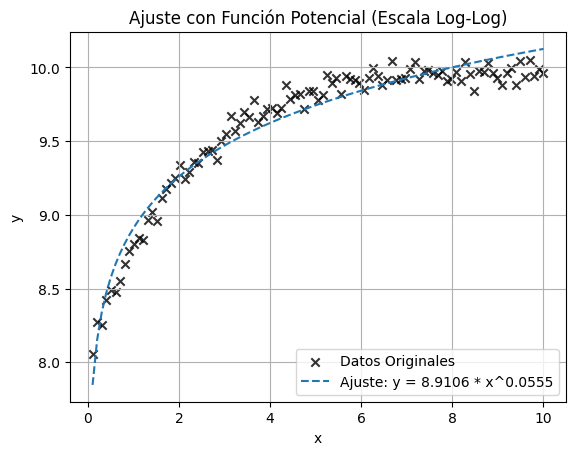

In [27]:
# Generar predicciones con el modelo ajustado.
x_fit_nonzero = np.linspace(min(x_nonzero), max(x_nonzero), 100)
y_fit_manual = power_law(x_fit_nonzero, a0_manual, a1_manual)

# Graficar los resultados
plt.scatter(x_nonzero, y_nonzero, label="Datos Originales", color="black", marker='x', alpha=0.8)
plt.plot(x_fit_nonzero, y_fit_manual, label=f"Ajuste: y = {a0_manual:.4f} * x^{a1_manual:.4f}", linestyle='--')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Ajuste con Función Potencial (Escala Log-Log)")
plt.grid(True)
plt.savefig("../figures/informe-01/funcion_potencial.png")
plt.show()

In [28]:
# Calcular coeficientes y métricas de R^2.
df_results = pd.DataFrame([{
    "Grado": 1,  # Ajuste de grado 1 en la escala log-log
    "Coeficientes": f"a0 = {a0_manual:.6f}, a1 = {a1_manual:.6f}",
    "R^2": r2_score(y_nonzero, power_law(x_nonzero, a0_manual, a1_manual))  # Cálculo de R^2 con sklearn
}])
df_results

,Grado,Coeficientes,R^2
0,1,"a0 = 8.910626, a1 = 0.055504",0.954667


## **Ejercicio 4: Ajuste por Regresión No Lineal.**
En este ejercicio, se implementa el **ajuste por regresión no lineal**, una técnica utilizada para modelar relaciones entre variables cuando la función subyacente no es una combinación lineal de los parámetros. A diferencia de la **regresión lineal**, en la que se ajusta un polinomio mediante una combinación lineal de términos, la **regresión no lineal** permite representar modelos más complejos con dependencias exponenciales, logarítmicas u otras formas funcionales.

En este caso, se considerarán los siguientes modelos no lineales para ajustar los datos experimentales:

1.  **Modelo exponencial decreciente:** $f(x) = a_0 - a_1 e^{-a_2 x}$
2. **Modelo combinado lineal-exponencial:** $f(x) = a_0 x - a_1 e^{-a_2 x}$
3. **Modelo cuadrático-exponencial:** $f(x) = a_0 x^2 - a_1 e^{-a_2 x}$

Los coeficientes $a_0$, $a_1$, $a_2$ se determinan mediante **ajuste por mínimos cuadrados no lineales**, utilizando métodos iterativos como el **algoritmo de Levenberg-Marquardt**.

El objetivo de este ejercicio es encontrar los valores óptimos de los parámetros $a_0$, $a_1$, $a_2$ que minimicen el error entre los valores observados y los valores predichos por el modelo. Se compararán los resultados de cada ajuste y se visualizarán las curvas obtenidas junto con los datos experimentales.

#### Definición de funciones.
A continuación definimos los modelos no lineales que serán utilizados en este ejercicio.

In [29]:
def modelo_exponencial(x, a0, a1, a2):
    return a0 - a1 * np.exp(-a2 * x)

In [30]:
def modelo_lineal_exponencial(x, a0, a1, a2):
    return a0 * x - a1 * np.exp(-a2 * x)

In [31]:
def modelo_cuadratico_exponencial(x, a0, a1, a2):
    return a0 * x**2 - a1 * np.exp(-a2 * x)

In [32]:
# Modelos a resolver.
modelos = {
    "Modelo Exponencial": modelo_exponencial,
    "Modelo Lineal-Exponencial": modelo_lineal_exponencial,
    "Modelo Cuadrático-Exponencial": modelo_cuadratico_exponencial
}

# Parámetros iniciales para cada modelo.
parametros_iniciales = {
    "Modelo Exponencial": [10, 5, 0.5],
    "Modelo Lineal-Exponencial": [1, 5, 0.5],
    "Modelo Cuadrático-Exponencial": [1, 5, 0.5]
}

#### Implementación de las funciones.

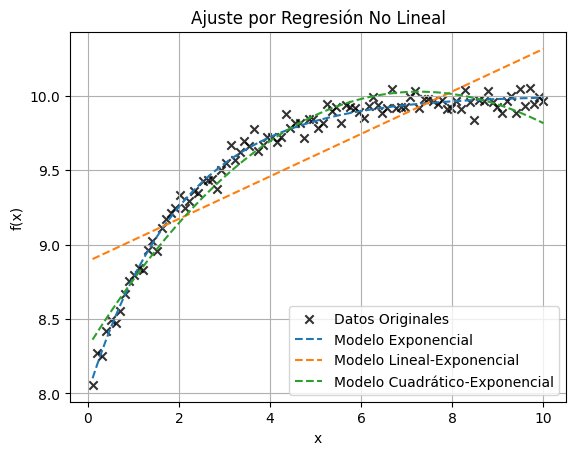

In [33]:
# Diccionario para almacenar los parámetros ajustados.
parametros_ajustados = {}

# Ajuste de los modelos.
for nombre, modelo in modelos.items():
    params_opt, _ = curve_fit(modelo, x_nonzero, y_nonzero, p0=parametros_iniciales[nombre])  # Ajuste con valores iniciales
    parametros_ajustados[nombre] = params_opt

# Graficar los modelos ajustados
x_fit = np.linspace(min(x_nonzero), max(x_nonzero), 200)
plt.scatter(x_nonzero, y_nonzero, color='black', label='Datos Originales', marker='x', alpha=0.8)
for i, (nombre, params) in enumerate(parametros_ajustados.items()):
    y_fit = modelos[nombre](x_fit, *params)
    plt.plot(x_fit, y_fit, linestyle='--', label=nombre, zorder=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title('Ajuste por Regresión No Lineal')
plt.grid(True)
plt.savefig("../figures/informe-01/regresion_no_lineal.png")
plt.show()

In [34]:
r2_scores = {}

# Cálculo de R^2 para cada modelo ajustado.
for nombre, params in parametros_ajustados.items():
    y_pred = modelos[nombre](x_vals, *params)
    r2_scores[nombre] = r2_score(y_vals, y_pred)

df_results = pd.DataFrame([
    {
        "Modelo": nombre,
        "Coeficientes": f"a0 = {params[0]:.6f}, a1 = {params[1]:.6f}, a2 = {params[2]:.6f}",
        "R^2": r2_scores[nombre]
    }
    for nombre, params in parametros_ajustados.items()
])

df_results

,Modelo,Coeficientes,R^2
0,Modelo Exponencial,"a0 = 10.001867, a1 = 1.996453, a2 = 0.491807",0.990798
1,Modelo Lineal-Exponencial,"a0 = 0.142599, a1 = -8.888500, a2 = -0.000003",0.724177
2,Modelo Cuadrático-Exponencial,"a0 = -0.051837, a1 = -8.312542, a2 = -0.059025",0.965157
